In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from pandas_datareader import data as pdr
import yfinance as yf

In [ ]:
def get_data(stocks, start, end):
  stockData = yf.download(stocks, start=start, end=end)
  stockData = stockData['Close']
  returns = stockData.pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

In [ ]:
stockList = ['CBA', 'BHP', 'TLS', 'NAB', 'WBC', 'STO']
stocks = [stock + '.AX' for stock in stockList]
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=300)

In [ ]:
meanReturns, covMatrix =get_data(stocks, startDate, endDate)

/tmp/ipython-input-419439221.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockData = yf.download(stocks, start=start, end=end)
[*********************100%***********************]  6 of 6 completed


In [ ]:
weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)

In [ ]:
print(weights)

[0.16671698 0.30327721 0.20306815 0.0514502  0.271767   0.00372046]


In [ ]:
# Monte Carlo Method
# numbers of simulations
mc_sims = 100
T = 10 #timeframe in days

In [ ]:
meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

In [ ]:
portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

In [ ]:
initialportfolio = 10000

In [ ]:
for m in range(0, mc_sims):
  # MC loops
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + L @ Z.T
  portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialportfolio

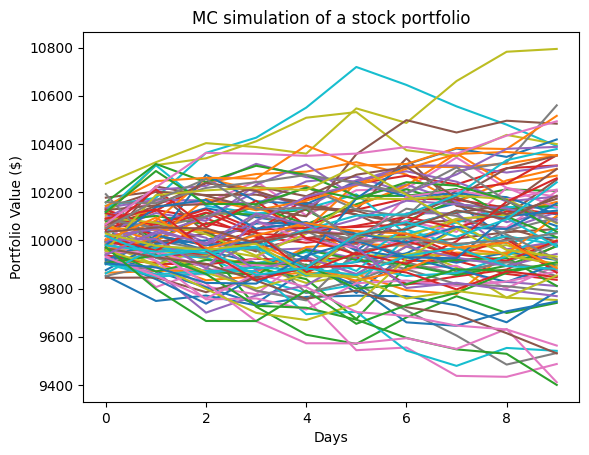

In [ ]:
plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.title('MC simulation of a stock portfolio')
plt.show()
